In [5]:
##Nạp thư viện, dữ liệu

In [6]:
import numpy as np
import scipy.sparse as sp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

X_train = sp.load_npz('../data/X_train.npz').toarray()
X_test = sp.load_npz('../data/X_test.npz').toarray()
y_train = np.load('../data/y_train.npy')
y_test = np.load('../data/y_test.npy')

y_train_svm = np.where(y_train == 0, -1, 1) #chuyển DL thành -1 1 vì dùng mô hình hàm mất mát hinge loss
y_test_svm = np.where(y_test == 0, -1, 1)

In [7]:
##Huấn luyên navie và log ( chỉ để so sánh sau này ) 

In [8]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [9]:
##CUSTOM SVM

In [10]:
class CustomLinearSVM:
    def __init__(self, learning_rate=0.001, C=1.0, n_iters=1000):
        self.lr = learning_rate
        self.C = C
        self.n_iters = n_iters
        self.w = None
        self.b = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0

        for _ in range(self.n_iters):
            margins = y * (np.dot(X, self.w) + self.b)
            misclassified_mask = margins < 1

            X_misclassified = X[misclassified_mask]
            y_misclassified = y[misclassified_mask]

            dw = self.w - self.C * np.dot(X_misclassified.T, y_misclassified)
            db = -self.C * np.sum(y_misclassified)

            self.w -= self.lr * dw
            self.b -= self.lr * db

    def predict(self, X):
        approx = np.dot(X, self.w) + self.b
        return np.sign(approx)

In [11]:
##CUSTOM NAIVE BAYES

In [12]:
class CustomMultinomialNB:
    def __init__(self, alpha=1.0):
        self.alpha = alpha  # Laplace smoothing
        self.classes = None
        self.class_priors = None
        self.feature_probs = None

    def fit(self, X, y):
        self.classes = np.unique(y)
        n_samples, n_features = X.shape
        self.class_priors = np.zeros(len(self.classes))
        self.feature_probs = np.zeros((len(self.classes), n_features))

        for idx, cls in enumerate(self.classes):
            X_cls = X[y == cls]
            self.class_priors[idx] = len(X_cls) / n_samples
            # Add alpha for smoothing
            feature_counts = X_cls.sum(axis=0) + self.alpha
            total_counts = feature_counts.sum()
            self.feature_probs[idx] = feature_counts / total_counts

    def predict(self, X):
        log_probs = np.zeros((X.shape[0], len(self.classes)))
        for idx, cls in enumerate(self.classes):
            log_prior = np.log(self.class_priors[idx])
            log_likelihood = X @ np.log(self.feature_probs[idx])
            log_probs[:, idx] = log_prior + log_likelihood
        return self.classes[np.argmax(log_probs, axis=1)]

In [13]:
##CUSTOM LOGISTIC REGRESSION

In [14]:
class CustomLogisticRegression:
    def __init__(self, learning_rate=0.01, n_iters=1000):
        self.lr = learning_rate
        self.n_iters = n_iters
        self.weights = None
        self.bias = None

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.n_iters):
            linear_model = np.dot(X, self.weights) + self.bias
            y_predicted = self.sigmoid(linear_model)

            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / n_samples) * np.sum(y_predicted - y)

            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    def predict(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        y_predicted = self.sigmoid(linear_model)
        return np.where(y_predicted > 0.5, 1, 0)

In [15]:
##Huấn luyện Custom SVM và Sklearn SVM ( cùng train để so sánh trực quan sau này )

In [16]:
custom_svm = CustomLinearSVM(learning_rate=0.01, C=1.0, n_iters=1500)
custom_svm.fit(X_train, y_train_svm)

custom_nb = CustomMultinomialNB(alpha=1.0)
custom_nb.fit(X_train, y_train)

custom_lr = CustomLogisticRegression(learning_rate=0.01, n_iters=1000)
custom_lr.fit(X_train, y_train)

sklearn_svm = SVC(kernel='linear', C=1.0)
sklearn_svm.fit(X_train, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [17]:
##Đánh giá thông minh và Vẽ biểu đồ

,Accuracy,Precision,Recall,F1-Score
Sklearn Naive Bayes,0.992045,1.000000,0.981579,0.990704
Sklearn Logistic Reg,0.990909,0.997326,0.981579,0.989390
Custom Naive Bayes,0.992045,1.000000,0.981579,0.990704
Custom Logistic Reg,0.953409,0.985673,0.905263,0.943759
Custom SVM,0.992045,0.986945,0.994737,0.990826
Sklearn SVM,0.992045,0.997333,0.984211,0.990728


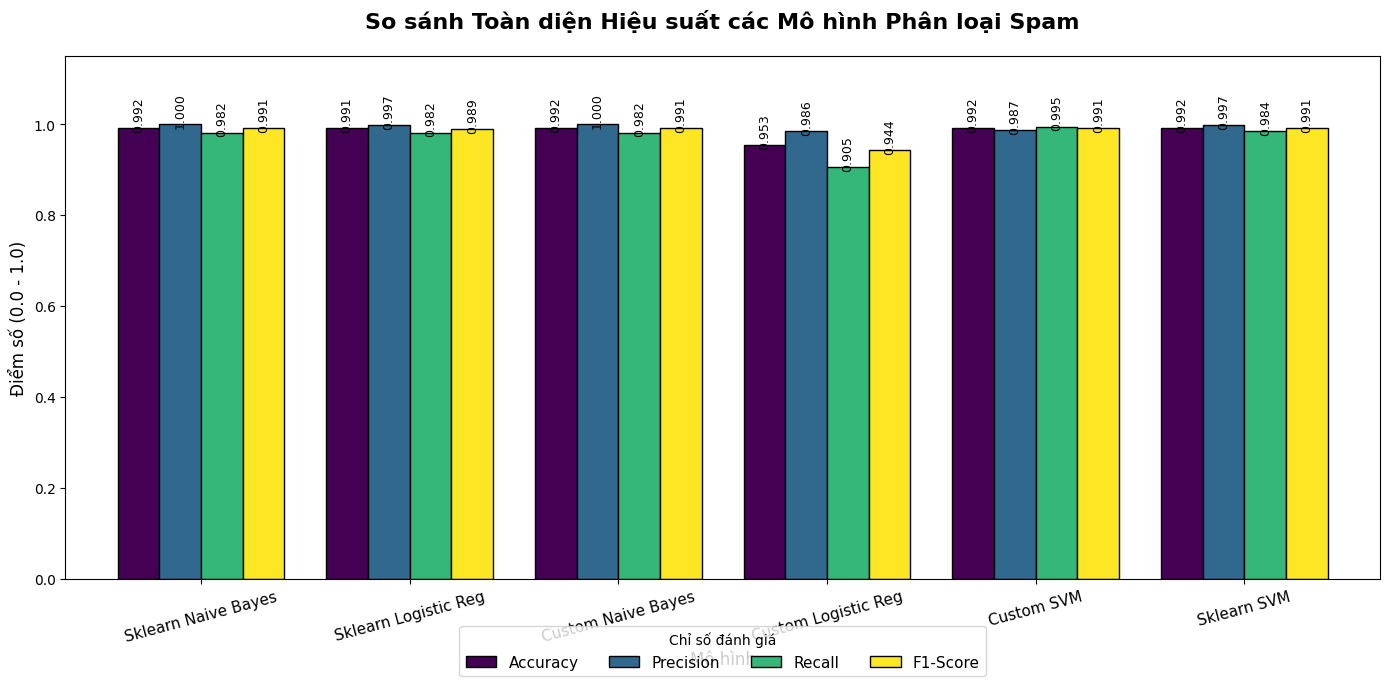

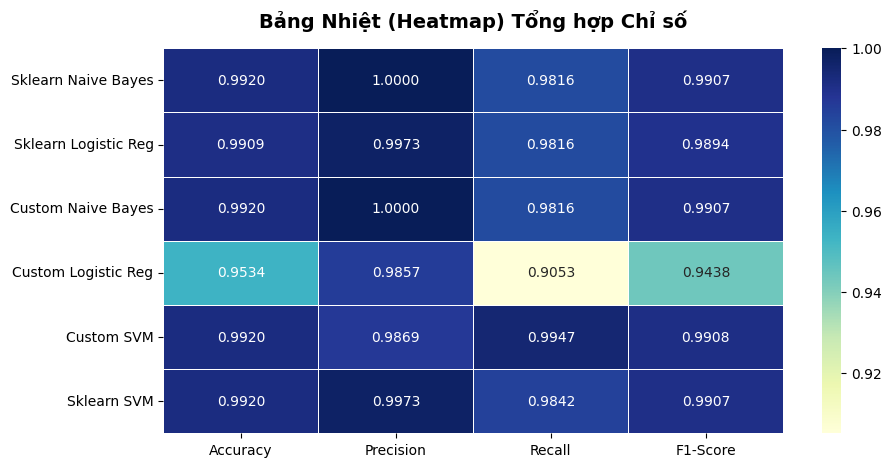

In [ ]:
models = ['Sklearn Naive Bayes', 'Custom Naive Bayes', 'Sklearn Logistic Reg', 'Custom Logistic Reg', 'Sklearn SVM', 'Custom SVM']
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

df_metrics = pd.DataFrame([metrics_nb, metrics_nb_custom, metrics_lr, metrics_lr_custom, metrics_svm_sklearn, metrics_svm_custom], 
                          columns=metrics_names, index=models)